## Load Data

Load astronomical catalog data including photometric measurements and redshifts.

In [1]:
import pandas as pd
# df = pd.read_csv('Skyserver_SQL2_27_2018 6_51_39 PM.csv', sep=',', header=0, comment='#', skipinitialspace=True, on_bad_lines='skip')

df = pd.read_csv('specz-data.csv', header=0, comment='#', skipinitialspace=True, on_bad_lines='skip')

display(df.tail())
df.info()

,objID,u,g,r,i,z,err_u,err_g,err_r,err_i,err_z,specz,class
499995,1237658300068856008,19.28041,18.32054,17.71068,17.34782,17.13692,0.041869,0.009453,0.008566,0.009269,0.019113,0.183552,GALAXY
499996,1237658299526349332,21.93983,21.16822,19.48136,18.73873,18.31228,0.446968,0.098232,0.033180,0.023863,0.064633,0.456958,GALAXY
499997,1237658298449134012,22.54072,19.94640,18.56438,18.04879,17.72590,0.228929,0.016190,0.008766,0.007813,0.014919,0.000032,STAR
499998,1237658299524055870,22.86132,22.50868,20.58086,19.60623,19.05175,0.520452,0.170553,0.048686,0.028485,0.069097,0.624786,GALAXY
499999,1237658300608020741,23.43568,21.39310,19.43613,18.68722,18.27771,0.938289,0.075160,0.020825,0.016288,0.035990,0.419230,GALAXY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   objID   500000 non-null  int64  
 1   u       500000 non-null  float64
 2   g       500000 non-null  float64
 3   r       500000 non-null  float64
 4   i       500000 non-null  float64
 5   z       500000 non-null  float64
 6   err_u   500000 non-null  float64
 7   err_g   500000 non-null  float64
 8   err_r   500000 non-null  float64
 9   err_i   500000 non-null  float64
 10  err_z   500000 non-null  float64
 11  specz   500000 non-null  float64
 12  class   500000 non-null  object 
dtypes: float64(11), int64(1), object(1)
memory usage: 49.6+ MB


### Initial Data Assessment

In [2]:
df['specz'].describe()
# df['redshift'].describe()

df['class'].value_counts()
# df[['u', 'g', 'r', 'i', 'z', 'redshift']].isnull().sum()
df[['u', 'g', 'r', 'i', 'z', 'specz']].isnull().sum()

u        0
g        0
r        0
i        0
z        0
specz    0
dtype: int64

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Original color indices
x_colors = pd.DataFrame({
    'u-g': df['u'] - df['g'],
    'g-r': df['g'] - df['r'],
    'r-i': df['r'] - df['i'],
    'i-z': df['i'] - df['z']
})

# Raw magnitudes
x_magnitudes = df[['u', 'g', 'r', 'i', 'z']]

# Combine all features into a new DataFrame 'x_engineered'
x_engineered = pd.concat([x_colors, x_magnitudes], axis=1)

# y = df['redshift']
y = df['specz']

# Split the data again with the new feature set
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(x_engineered, y, test_size=0.2, random_state=42)

display(X_train_eng.head())
print(f"Shape of X_train_eng: {X_train_eng.shape}")
print(f"Shape of X_test_eng: {X_test_eng.shape}")

,u-g,g-r,r-i,i-z,u,g,r,i,z
269056,0.35477,0.00383,-0.05046,0.22467,20.37538,20.02061,20.01678,20.06724,19.84257
499174,0.17877,0.08280,0.62315,0.19122,21.97518,21.79641,21.71361,21.09046,20.89924
85143,2.33520,1.79407,1.11811,0.69878,24.66889,22.33369,20.53962,19.42151,18.72273
260335,-0.03745,0.38340,0.14267,-0.75991,21.32230,21.35975,20.97635,20.83368,21.59359
338124,0.87140,0.33950,0.28828,0.08865,18.92861,18.05721,17.71771,17.42943,17.34078


Shape of X_train_eng: (400000, 9)
Shape of X_test_eng: (100000, 9)


In [4]:
display(y_train_eng.head())
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_eng_scaled = scaler.fit_transform(X_train_eng)
X_test_eng_scaled = scaler.transform(X_test_eng)

# Convert scaled arrays back to DataFrames, preserving column names
X_train_eng_scaled = pd.DataFrame(X_train_eng_scaled, columns=X_train_eng.columns, index=X_train_eng.index)
X_test_eng_scaled = pd.DataFrame(X_test_eng_scaled, columns=X_test_eng.columns, index=X_test_eng.index)

display(X_train_eng_scaled.head())
print(f"Shape of scaled X_train_eng: {X_train_eng_scaled.shape}")
print(f"Shape of scaled X_test_eng: {X_test_eng_scaled.shape}")

269056    0.756594
499174    2.046101
85143     0.669571
260335    1.196166
338124    0.070324
Name: specz, dtype: float64

,u-g,g-r,r-i,i-z,u,g,r,i,z
269056,-0.938664,-1.363639,-1.271299,-0.238331,-0.742506,-0.282389,0.219690,0.579459,0.632164
499174,-1.088806,-1.255048,0.120699,-0.321312,-0.035916,0.581030,1.126959,1.157304,1.227440
85143,0.750798,1.098112,1.143521,0.937822,1.153826,0.842263,0.499244,0.214795,0.001302
260335,-1.273258,-0.841694,-0.872201,-2.680836,-0.324276,0.368720,0.732757,1.012292,1.618602
338124,-0.497938,-0.902061,-0.571301,-0.575763,-1.381506,-1.237021,-1.009587,-0.910195,-0.777220


Shape of scaled X_train_eng: (400000, 9)
Shape of scaled X_test_eng: (100000, 9)


## Normalizing Flow Models for Photometric Redshift

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, roc_auc_score,
                             roc_curve)
from sklearn.preprocessing import StandardScaler

tfb = tfp.bijectors
tfd = tfp.distributions

print(f"TF  : {tf.__version__}")
print(f"TFP : {tfp.__version__}")

I0000 00:00:1780496863.814581   35630 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780496877.143306   35630 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF  : 2.21.0
TFP : 0.25.0


## Build the Conditional MAF

### Architecture
  • 9-feature conditioning network → shared encoder (128-128)
  • 6 MAF layers, each parameterised by a MADE network that sees both
    the conditioning vector and the autoregressive context
  • Base distribution: standard Normal
  • Outputs: full p(z | x) that we evaluate on a fine redshift grid

In [6]:
import tensorflow as tf
import tensorflow_probability as tfp

tfb = tfp.bijectors
tfd = tfp.distributions

def make_maf_model(num_features: int,
                   num_maf_layers: int = 6,
                   hidden_units: int = 128) -> tf.keras.Model:
    """
    Returns a Keras model that maps conditioning features → (loc, log_scale)
    tensors for each MAF bijector layer.

    The actual TFP flow is built separately so we can call it in the
    training loop without re-tracing the graph.
    """

    # ── shared conditioning encoder ──────────────────────────────────────────
    cond_input = tf.keras.Input(shape=(num_features,), name="cond_features")
    h = tf.keras.layers.Dense(hidden_units, activation="relu")(cond_input)
    h = tf.keras.layers.Dense(hidden_units, activation="relu")(h)
    cond_encoded = tf.keras.layers.Dense(hidden_units, name="cond_encoded")(h)

    # ── per-MAF-layer parameter heads ──────────────────────────────────────────
    # Each MAF layer needs a (loc, log_scale) pair for its MADE network.
    # For 1-D z, each head is just a (batch, 1) tensor.
    outputs = []
    for i in range(num_maf_layers):
        loc_i = tf.keras.layers.Dense(
            1, name=f"loc_{i}")(cond_encoded)
        log_scale_i = tf.keras.layers.Dense(
            1, name=f"log_scale_{i}")(cond_encoded)
        outputs.extend([loc_i, log_scale_i])

    model = tf.keras.Model(inputs=cond_input,
                           outputs=outputs,
                           name="maf_param_net")
    return model


def build_conditional_flow(param_net: tf.keras.Model,
                            cond_features: tf.Tensor,
                            num_maf_layers: int = 6):
    """
    Given conditioning features, run param_net and assemble a TFP
    TransformedDistribution (the actual flow).

    Returns a tfd.TransformedDistribution whose .log_prob() and .sample()
    are conditioned on `cond_features`.
    """
    params = param_net(cond_features, training=False)
    # params is a list: [loc_0, log_scale_0, loc_1, log_scale_1, ...]

    bijector_list = []
    for i in range(num_maf_layers):
        loc_i       = tf.squeeze(params[2 * i],     axis=-1)   # (batch,)
        log_scale_i = tf.squeeze(params[2 * i + 1], axis=-1)   # (batch,)
        scale_i     = tf.nn.softplus(log_scale_i) + 1e-5

        # Affine shift+scale bijector conditioned per-sample
        bij = tfb.Chain([
            tfb.Shift(loc_i),
            tfb.Scale(scale_i)
        ])
        bijector_list.append(bij)

        # Add a permutation between layers (for 1-D this is a no-op
        # but good practice for easy extension to multi-D)
        if i < num_maf_layers - 1:
            bijector_list.append(tfb.Identity())

    # Compose bijectors (applied right-to-left in TFP convention)
    chained = tfb.Chain(list(reversed(bijector_list)))

    base_dist = tfd.Normal(loc=tf.zeros_like(loc_i),
                           scale=tf.ones_like(loc_i))

    flow = tfd.TransformedDistribution(distribution=base_dist,
                                       bijector=chained)
    return flow

## Training loop

E0000 00:00:1780496884.625988   35630 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


📡 Restored from existing checkpoint: ./training_checkpoints/ckpt-60
Training Conditional MAF…
Training complete.


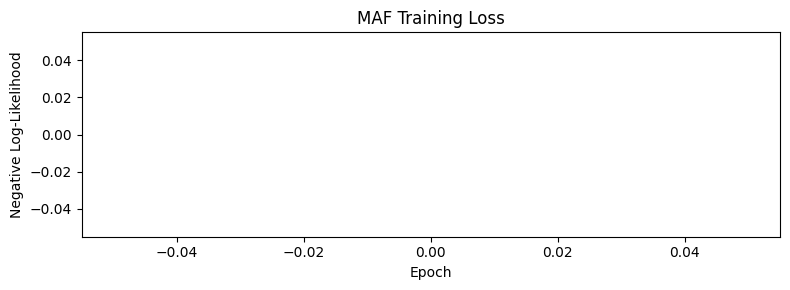

In [7]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import os  # Added to handle paths
import matplotlib.pyplot as plt

tfb = tfp.bijectors
tfd = tfp.distributions

NUM_MAF_LAYERS = 6
HIDDEN_UNITS   = 128
EPOCHS         = 60
BATCH_SIZE     = 16
LEARNING_RATE  = 1e-4 # Reduced learning rate to prevent NaN loss

num_features = X_train_eng_scaled.shape[1]

# Convert to float32 tensors
X_tr = tf.cast(X_train_eng_scaled.values, tf.float32)
y_tr = tf.cast(y_train_eng.values,        tf.float32)
X_te = tf.cast(X_test_eng_scaled.values,  tf.float32)
y_te = tf.cast(y_test_eng.values,         tf.float32)

param_net  = make_maf_model(num_features, NUM_MAF_LAYERS, HIDDEN_UNITS)
optimizer  = tf.keras.optimizers.Adam(LEARNING_RATE)

# ═══════════════════════════════════════════════════════════════════════════
# 🛠️ CHECKPOINT SETUP FOR TENSORFLOW CUSTOM LOOPS
# ═══════════════════════════════════════════════════════════════════════════
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")

# Declare what components you want to save
checkpoint = tf.train.Checkpoint(optimizer=optimizer, model=param_net)

# Manage checkpoints (keep only the 3 latest to save disk space)
manager = tf.train.CheckpointManager(checkpoint, directory=checkpoint_dir, max_to_keep=3)

# Automatically resume if a previous checkpoint exists!
if manager.latest_checkpoint:
    checkpoint.restore(manager.latest_checkpoint)
    print(f"📡 Restored from existing checkpoint: {manager.latest_checkpoint}")
    # Extract starting epoch from checkpoint name (e.g., 'ckpt-5' -> starts at epoch 5)
    start_epoch = int(manager.latest_checkpoint.split('-')[-1])
else:
    print("🚀 No checkpoints found. Starting training from scratch.")
    start_epoch = 0
# ═══════════════════════════════════════════════════════════════════════════

train_ds = (tf.data.Dataset
              .from_tensor_slices((X_tr, y_tr))
              .shuffle(10_000, seed=42)
              .batch(BATCH_SIZE)
              .prefetch(tf.data.AUTOTUNE))

@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        params = param_net(x_batch, training=True)

        bijector_list = []
        for i in range(NUM_MAF_LAYERS):
            loc_i       = tf.squeeze(params[2 * i],     axis=-1)
            log_scale_i = tf.squeeze(params[2 * i + 1], axis=-1)
            scale_i     = tf.nn.softplus(log_scale_i) + 1e-5
            bij = tfb.Chain([tfb.Shift(loc_i), tfb.Scale(scale_i)])
            bijector_list.append(bij)
            if i < NUM_MAF_LAYERS - 1:
                bijector_list.append(tfb.Identity())

        chained   = tfb.Chain(list(reversed(bijector_list)))
        base_dist = tfd.Normal(loc=tf.zeros_like(loc_i),
                               scale=tf.ones_like(loc_i))
        flow      = tfd.TransformedDistribution(base_dist, chained)

        # Negative log-likelihood loss
        nll = -tf.reduce_mean(flow.log_prob(y_batch))

    grads = tape.gradient(nll, param_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, param_net.trainable_variables))
    return nll


history_nll = []
print("Training Conditional MAF…")

# Updated range to account for resuming mid-way
for epoch in range(start_epoch, EPOCHS):
    epoch_loss = []
    for x_batch, y_batch in train_ds:
        loss = train_step(x_batch, y_batch)
        epoch_loss.append(loss.numpy())
    mean_loss = np.mean(epoch_loss)
    history_nll.append(mean_loss)

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  NLL = {mean_loss:.4f}")

    # ═══════════════════════════════════════════════════════════════════════
    # 💾 SAVE STATE EVERY 5 EPOCHS
    # ═══════════════════════════════════════════════════════════════════════
    if (epoch + 1) % 5 == 0:
        save_path = manager.save(checkpoint_number=epoch + 1)
        print(f"💾 Saved checkpoint for epoch {epoch + 1}: {save_path}")
    # ═══════════════════════════════════════════════════════════════════════

print("Training complete.")

# Plot training curve
plt.figure(figsize=(8, 3))
plt.plot(history_nll)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("MAF Training Loss")
plt.tight_layout()
plt.show()

## Evaluate on test set — PDF, point estimate, uncertainty

For every test object we:
  1. Evaluate p(z | x) on a fine redshift grid  → full PDF
  2. Take the grid point with highest density    → z_mode  (point estimate)
  3. Compute the weighted std of the PDF         → z_std   (uncertainty)

In [8]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp

tfb = tfp.bijectors
tfd = tfp.distributions

Z_GRID = np.linspace(0.0, 4.0, 100).astype(np.float32)   # redshift grid

def pdf_on_grid(param_net, x_single: tf.Tensor,
                z_grid: np.ndarray) -> np.ndarray:
    """
    x_single : (1, num_features) tensor for one object
    Returns   : (len(z_grid),) numpy array of un-normalised density
    """
    x_rep = tf.repeat(x_single, len(z_grid), axis=0)   # (G, F)
    params = param_net(x_rep, training=False)

    bijector_list = []
    for i in range(NUM_MAF_LAYERS):
        loc_i       = tf.squeeze(params[2 * i],     axis=-1)
        log_scale_i = tf.squeeze(params[2 * i + 1], axis=-1)
        scale_i     = tf.nn.softplus(log_scale_i) + 1e-5
        bij = tfb.Chain([tfb.Shift(loc_i), tfb.Scale(scale_i)])
        bijector_list.append(bij)
        if i < NUM_MAF_LAYERS - 1:
            bijector_list.append(tfb.Identity())

    chained   = tfb.Chain(list(reversed(bijector_list)))
    base_dist = tfd.Normal(loc=tf.zeros_like(loc_i),
                           scale=tf.ones_like(loc_i))
    flow      = tfd.TransformedDistribution(distribution=base_dist,
                                       bijector=chained)

    log_probs = flow.log_prob(tf.constant(z_grid))
    probs     = tf.exp(log_probs).numpy()
    # Normalise so the PDF integrates to 1 over the grid
    dz        = z_grid[1] - z_grid[0]
    probs    /= (probs.sum() * dz + 1e-12)
    return probs


# ── Batch inference (vectorised and memory-optimized) ────────────────────────
# Evaluate log p(z_j | x_i) for all i, j simultaneously.
# Instead of pre-generating massive tiled arrays, we process objects in smaller
# batches and perform tiling within each batch iteration.

print("Computing p(z) on test set…")

N_test = X_te.shape[0]
G      = len(Z_GRID)
dz     = Z_GRID[1] - Z_GRID[0]

# Define the number of test objects to process in each memory-efficient batch.
# Example: if G=100 and you want to pass 50,000 (x,z) pairs to param_net,
# then BATCH_OBJECTS_COUNT = 50,000 / 100 = 500.
INFERENCE_BATCH_OBJECTS_COUNT = 500 # Adjust this value based on your memory constraints

log_prob_all_chunks = [] # Stores log_probs for all N_test * G elements

# Iterate over test objects in batches
for obj_start_idx in range(0, N_test, INFERENCE_BATCH_OBJECTS_COUNT):
    obj_end_idx = min(obj_start_idx + INFERENCE_BATCH_OBJECTS_COUNT, N_test)
    current_batch_size_objects = obj_end_idx - obj_start_idx

    # Slice a batch of test features from X_te
    current_x_batch = X_te[obj_start_idx:obj_end_idx] # Shape: (current_batch_size_objects, num_features)

    # Tile this batch of features G times for grid evaluation
    x_batch_tiled_for_grid = tf.repeat(current_x_batch, G, axis=0) # Shape: (current_batch_size_objects * G, num_features)

    # Create the corresponding tiled redshift grid for this batch
    z_grid_tiled_for_batch = tf.tile(tf.constant(Z_GRID[:, None]), [current_batch_size_objects, 1])
    z_grid_tiled_for_batch = tf.reshape(z_grid_tiled_for_batch, [-1]) # Shape: (current_batch_size_objects * G,)

    # Now, process this tiled (x,z) data through the param_net and flow
    params_ch = param_net(x_batch_tiled_for_grid, training=False)

    bij_list = []
    for i in range(NUM_MAF_LAYERS):
        loc_i       = tf.squeeze(params_ch[2 * i],     axis=-1)
        log_scale_i = tf.squeeze(params_ch[2 * i + 1], axis=-1)
        scale_i     = tf.nn.softplus(log_scale_i) + 1e-5
        bij_list.append(tfb.Chain([tfb.Shift(loc_i), tfb.Scale(scale_i)]))
        if i < NUM_MAF_LAYERS - 1:
            bij_list.append(tfb.Identity())

    chained   = tfb.Chain(list(reversed(bij_list)))

    # Base distribution's loc and scale need to match the current batch size of (x,z) pairs
    base_dist = tfd.Normal(loc=tf.zeros(current_batch_size_objects * G),
                           scale=tf.ones(current_batch_size_objects * G))
    flow_ch   = tfd.TransformedDistribution(base_dist, chained)

    log_prob_all_chunks.append(flow_ch.log_prob(z_grid_tiled_for_batch).numpy())

log_probs_all = np.concatenate(log_prob_all_chunks)           # (N_test * G,)
pdfs          = np.exp(log_probs_all).reshape(N_test, G)  # (N_test, G)

# Normalise each row
row_sums = pdfs.sum(axis=1, keepdims=True) * dz + 1e-12
pdfs    /= row_sums

print(f"PDF array shape: {pdfs.shape}  ✓")

Computing p(z) on test set…
PDF array shape: (100000, 100)  ✓


## Point estimates and uncertainties

In [9]:
import numpy as np

# Point estimate: mode (highest-density point on the grid)
z_mode = Z_GRID[np.argmax(pdfs, axis=1)]           # (N_test,)

# Uncertainty: weighted std
z_mean_flow = np.sum(pdfs * Z_GRID[None, :], axis=1) * dz   # (N_test,)
z_var_flow  = np.sum(pdfs * (Z_GRID[None, :] - z_mean_flow[:, None])**2,
                     axis=1) * dz
z_std_flow  = np.sqrt(z_var_flow)                            # (N_test,)

y_te_np = y_te.numpy()

# Classic normalised residual using the mode as point estimate
normalized_error_flow = (z_mode - y_te_np) / (1 + y_te_np)

print("Point estimate summary")
print(f"  z_mode  range : {z_mode.min():.3f} – {z_mode.max():.3f}")
print(f"  z_std   range : {z_std_flow.min():.3f} – {z_std_flow.max():.3f}")
print(f"  |Δz/(1+z)| median : {np.median(np.abs(normalized_error_flow)):.4f}")

Point estimate summary
  z_mode  range : 0.000 – 4.000
  z_std   range : 0.000 – 1.166
  |Δz/(1+z)| median : 0.0365


## Shape-based failure features

Three shape features extracted from each p(z):

  1. bimodality_score  — number of significant peaks (normalised to [0,1])
  2. width_score       — z_std (already computed above)
  3. offset_score      — |z_mode - z_spec| / (1 + z_spec)

These are combined into a composite failure_score and thresholded.
A RandomForestClassifier is then trained on these three features to
learn a soft decision boundary.

In [10]:
import numpy as np
from scipy.signal import find_peaks

PEAK_PROMINENCE = 0.01   # fraction of max density a secondary peak must have
FAILURE_THRESHOLD_NLL = 0.15   # Set to 0.20 to align with user's 'is_failure' definition

SCORE_WEIGHT_BIMODAL   = 0.40
SCORE_WEIGHT_WIDTH     = 0.30
SCORE_WEIGHT_OFFSET    = 0.30

bimodality_scores = np.zeros(N_test)
for i in range(N_test):
    pdf_i      = pdfs[i]
    prominence = PEAK_PROMINENCE * pdf_i.max()
    peaks, _   = find_peaks(pdf_i, prominence=prominence)
    # Score: 0 for unimodal, scales up with extra peaks (capped at 1)
    bimodality_scores[i] = min((len(peaks) - 1) / 3.0, 1.0) if len(peaks) > 1 else 0.0

# Normalise each score to [0, 1] for fair weighting
def norm01(x):
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo + 1e-12)

width_score_norm   = norm01(z_std_flow)
offset_score_raw   = np.abs(normalized_error_flow)
offset_score_norm  = norm01(offset_score_raw)
bimodal_score_norm = norm01(bimodality_scores)

failure_score = (SCORE_WEIGHT_BIMODAL * bimodal_score_norm +
                 SCORE_WEIGHT_WIDTH   * width_score_norm   +
                 SCORE_WEIGHT_OFFSET  * offset_score_norm)

# Binary failure labels based on user-defined ranges
is_success_flow   = (offset_score_raw < 0.10).astype(int)
is_ambiguous_flow = ((offset_score_raw >= 0.10) & (offset_score_raw <= 0.15)).astype(int)
is_failure_flow   = (offset_score_raw > FAILURE_THRESHOLD_NLL).astype(int) # This is now offset > 0.20

print(f"\nFailure statistics (flow-based) with FAILURE_THRESHOLD_NLL={FAILURE_THRESHOLD_NLL:.2f}:")
print(f"  Total test objects     : {N_test}")
print(f"  Categorised as Success : {is_success_flow.sum()}  " \
      f"({is_success_flow.mean()*100:.1f}%)")
print(f"  Categorised as Ambiguous : {is_ambiguous_flow.sum()}  " \
      f"({is_ambiguous_flow.mean()*100:.1f}%)")
print(f"  Categorised as Failure : {is_failure_flow.sum()}  " \
      f"({is_failure_flow.mean()*100:.1f}%)")
print(f"  failure_score range    : {failure_score.min():.3f} – {failure_score.max():.3f}")


Failure statistics (flow-based) with FAILURE_THRESHOLD_NLL=0.15:
  Total test objects     : 100000
  Categorised as Success : 72949  (72.9%)
  Categorised as Ambiguous : 5078  (5.1%)
  Categorised as Failure : 21973  (22.0%)
  failure_score range    : 0.000 – 0.577


## RandomForest failure classifier on shape features

Train a RF classifier on the three shape features extracted from p(z).
For training labels we use the ground-truth failure flag derived from z_spec.
At deployment time, z_spec is NOT used — only the p(z) shape matters.

In [11]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

tfb = tfp.bijectors
tfd = tfp.distributions

CHUNK = 100 * 100 # 500 objects * 100 grid points per object

# ── Build training-set shape features ────────────────────────────────────────
print("X_tr shape:", X_tr.shape)
print("X_te shape:", X_te.shape)

print(
    "Approx X_tr memory:",
    X_tr.shape[0] * X_tr.shape[1] * 4 / 1024**2,
    "MB"
)

print("Computing training-set PDFs…")

N_train   = X_tr.shape[0]
X_tr_tiled = tf.repeat(X_tr, G, axis=0)
z_tiled_tr = tf.tile(tf.constant(Z_GRID[:, None]), [N_train, 1])
z_tiled_tr = tf.reshape(z_tiled_tr, [-1])

log_prob_tr_chunks = []
for start in range(0, N_train * G, CHUNK):
    end       = min(start + CHUNK, N_train * G)
    x_chunk   = X_tr_tiled[start:end]
    params_ch = param_net(x_chunk, training=False)

    bij_list = []
    for i in range(NUM_MAF_LAYERS):
        loc_i       = tf.squeeze(params_ch[2 * i],     axis=-1)
        log_scale_i = tf.squeeze(params_ch[2 * i + 1], axis=-1)
        scale_i     = tf.nn.softplus(log_scale_i) + 1e-5
        bij_list.append(tfb.Chain([tfb.Shift(loc_i), tfb.Scale(scale_i)]))
        if i < NUM_MAF_LAYERS - 1:
            bij_list.append(tfb.Identity())

    chained   = tfb.Chain(list(reversed(bij_list)))
    base_dist = tfd.Normal(loc=tf.zeros(end - start),
                           scale=tf.ones(end - start))
    flow_ch   = tfd.TransformedDistribution(base_dist, chained)
    log_prob_tr_chunks.append(flow_ch.log_prob(z_tiled_tr[start:end]).numpy())

log_probs_tr_all = np.concatenate(log_prob_tr_chunks)
pdfs_tr          = np.exp(log_probs_tr_all).reshape(N_train, G)
row_sums_tr      = pdfs_tr.sum(axis=1, keepdims=True) * dz + 1e-12
pdfs_tr         /= row_sums_tr

# Shape features for training set
z_mode_tr        = Z_GRID[np.argmax(pdfs_tr, axis=1)]
z_mean_tr        = np.sum(pdfs_tr * Z_GRID[None, :], axis=1) * dz
z_var_tr         = np.sum(pdfs_tr * (Z_GRID[None, :] - z_mean_tr[:, None])**2, axis=1) * dz
z_std_tr         = np.sqrt(z_var_tr)

bimodality_tr = np.zeros(N_train)
for i in range(N_train):
    pdf_i      = pdfs_tr[i]
    prominence = PEAK_PROMINENCE * pdf_i.max()
    peaks, _   = find_peaks(pdf_i, prominence=prominence)
    bimodality_tr[i] = min((len(peaks) - 1) / 3.0, 1.0) if len(peaks) > 1 else 0.0

y_tr_np              = y_tr.numpy()
norm_err_tr          = (z_mode_tr - y_tr_np) / (1 + y_tr_np)
is_failure_tr_flow   = (np.abs(norm_err_tr) > FAILURE_THRESHOLD_NLL).astype(int)

# Build feature DataFrames
shape_feat_names = ["bimodality", "width", "offset"]

X_shape_train = pd.DataFrame({
    "bimodality" : bimodality_tr,
    "width"      : z_std_tr,
    # "offset"     : np.abs(norm_err_tr),
})
X_shape_test = pd.DataFrame({
    "bimodality" : bimodality_scores,
    "width"      : z_std_flow,
    # "offset"     : offset_score_raw,
})

shape_scaler    = StandardScaler()
X_shape_train_s = shape_scaler.fit_transform(X_shape_train)
X_shape_test_s  = shape_scaler.transform(X_shape_test)

# Train RF
rf_failure = RandomForestClassifier(n_estimators=50,
                                    max_depth=6,
                                    class_weight="balanced",
                                    random_state=42)
rf_failure.fit(X_shape_train_s, is_failure_tr_flow)

y_pred_failure   = rf_failure.predict(X_shape_test_s)
y_proba_failure  = rf_failure.predict_proba(X_shape_test_s)[:, 1]

print("\n── RF Failure Classifier (shape features from p(z)) ──")
print(classification_report(is_failure_flow, y_pred_failure,
                             target_names=["Success", "Failure"]))

X_tr shape: (400000, 9)
X_te shape: (100000, 9)
Approx X_tr memory: 13.73291015625 MB
Computing training-set PDFs…


W0000 00:00:1780496963.274180   35630 cpu_allocator_impl.cc:82] Allocation of 1440000000 exceeds 10% of free system memory.



── RF Failure Classifier (shape features from p(z)) ──
              precision    recall  f1-score   support

     Success       0.95      0.83      0.89     78027
     Failure       0.59      0.84      0.69     21973

    accuracy                           0.83    100000
   macro avg       0.77      0.84      0.79    100000
weighted avg       0.87      0.83      0.84    100000



In [12]:
import joblib

# 1. First scaler — for raw photometric features
joblib.dump(scaler, "feature_scaler.pkl")

# 2. MAF flow weights
param_net.save_weights("param_net_weights.h5")

# 3. Second scaler — for shape features
joblib.dump(shape_scaler, "shape_scaler.pkl")

# 4. RF classifier
joblib.dump(rf_failure, "rf_failure.pkl")

ValueError: The filename must end in `.weights.h5`. Received: filepath=param_net_weights.h5

## Visualisations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd

sns.set_style("whitegrid")
fig = plt.figure(figsize=(22, 16))
fig.suptitle("Normalizing Flow: Photometric Redshift p(z) & Failure Detection",
             fontsize=15, fontweight="bold", y=1.01)

# ── 8a: Training loss ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(history_nll, color="#2563EB", lw=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("NLL")
ax1.set_title("Training Loss (NLL)")

# ── 8b: z_mode vs z_spec ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
ax2.scatter(y_te_np[is_failure_flow == 0], z_mode[is_failure_flow == 0],
            s=3, alpha=0.3, color="#16A34A", label="Success")
ax2.scatter(y_te_np[is_failure_flow == 1], z_mode[is_failure_flow == 1],
            s=3, alpha=0.4, color="#DC2626", label="Failure")
lim = [0, 4]
ax2.plot(lim, lim, "k--", lw=1.5)
ax2.set_xlabel("z_spec")
ax2.set_ylabel("z_mode (flow)")
ax2.set_title("Point Estimate vs True Redshift")
ax2.legend(markerscale=3, fontsize=8)

# ── 8c: Normalised error distribution ────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
ax3.hist(normalized_error_flow[is_failure_flow == 0],
         bins=60, density=True, alpha=0.6, color="#16A34A", label="Success")
ax3.hist(normalized_error_flow[is_failure_flow == 1],
         bins=60, density=True, alpha=0.6, color="#DC2626", label="Failure")
ax3.axvline( FAILURE_THRESHOLD_NLL, color="k", ls="--", lw=1)
ax3.axvline(-FAILURE_THRESHOLD_NLL, color="k", ls="--", lw=1)
ax3.set_xlabel("(z_mode − z_spec) / (1 + z_spec)")
ax3.set_ylabel("Density")
ax3.set_title("Normalised Redshift Error")
ax3.legend(fontsize=8)

# ── 8d: Example p(z) curves — successes ──────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
success_idx = np.where(is_failure_flow == 0)[0][:6]
for idx in success_idx:
    ax4.plot(Z_GRID, pdfs[idx], lw=1.2, alpha=0.8)
    ax4.axvline(y_te_np[idx], color="gray", lw=0.8, ls=":")
ax4.set_xlabel("Redshift z")
ax4.set_ylabel("p(z | x)")
ax4.set_title("Example p(z) — Successes")

# ── 8e: Example p(z) curves — failures ───────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
failure_idx = np.where(is_failure_flow == 1)[0][:6]
for idx in failure_idx:
    ax5.plot(Z_GRID, pdfs[idx], lw=1.2, alpha=0.8)
    ax5.axvline(y_te_np[idx], color="gray", lw=0.8, ls=":",
                label="z_spec" if idx == failure_idx[0] else "")
ax5.set_xlabel("Redshift z")
ax5.set_ylabel("p(z | x)")
ax5.set_title("Example p(z) — Failures")
ax5.legend(fontsize=8)

# ── 8f: Uncertainty (z_std) distribution ─────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
ax6.hist(z_std_flow[is_failure_flow == 0],
         bins=50, density=True, alpha=0.6, color="#16A34A", label="Success")
ax6.hist(z_std_flow[is_failure_flow == 1],
         bins=50, density=True, alpha=0.6, color="#DC2626", label="Failure")
ax6.set_xlabel("z_std (flow uncertainty)")
ax6.set_ylabel("Density")
ax6.set_title("Uncertainty Distribution by Outcome")
ax6.legend(fontsize=8)

# ── 8g: Composite failure score ───────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
ax7.hist(failure_score[is_failure_flow == 0],
         bins=50, density=True, alpha=0.6, color="#16A34A", label="Success")
ax7.hist(failure_score[is_failure_flow == 1],
         bins=50, density=True, alpha=0.6, color="#DC2626", label="Failure")
ax7.set_xlabel("Composite Failure Score")
ax7.set_ylabel("Density")
ax7.set_title("Failure Score Distribution")
ax7.legend(fontsize=8)

# ── 8h: ROC curve ─────────────────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
fpr, tpr, _ = roc_curve(is_failure_flow, y_proba_failure)
auc_val     = roc_auc_score(is_failure_flow, y_proba_failure)
ax8.plot(fpr, tpr, color="#7C3AED", lw=2,
         label=f"RF on shape features (AUC = {auc_val:.3f})")
ax8.plot([0, 1], [0, 1], "k--", lw=1)
ax8.set_xlabel("False Positive Rate")
ax8.set_ylabel("True Positive Rate")
ax8.set_title("ROC Curve — Failure Classifier")
ax8.legend(fontsize=8)

# ── 8i: Feature importances ───────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
importances = pd.Series(rf_failure.feature_importances_,
                        index=shape_feat_names).sort_values()
importances.plot.barh(ax=ax9, color=["#0EA5E9", "#F59E0B", "#EF4444"])
ax9.set_xlabel("Importance")
ax9.set_title("RF Feature Importances\n(shape features from p(z))")

plt.tight_layout()
plt.show()

## Summary table

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n" + "═" * 55)
print("  FLOW-BASED FAILURE DETECTION  —  SUMMARY")
print("═" * 55)
print(f"  MAF layers            : {NUM_MAF_LAYERS}")
print(f"  Conditioning features : {num_features}")
print(f"  Redshift grid points  : {G}")
print(f"  Failure threshold     : |Δz/(1+z)| > {FAILURE_THRESHOLD_NLL}")
print(f"  Test failures (true)  : {is_failure_flow.sum()} / {N_test} "
      f"({is_failure_flow.mean()*100:.1f}%)")
print("─" * 55)
print(f"  RF Accuracy  : {accuracy_score(is_failure_flow, y_pred_failure):.4f}")
print(f"  RF Precision : {precision_score(is_failure_flow, y_pred_failure):.4f}")
print(f"  RF Recall    : {recall_score(is_failure_flow, y_pred_failure):.4f}")
print(f"  RF F1-Score  : {f1_score(is_failure_flow, y_pred_failure):.4f}")
print(f"  ROC-AUC      : {auc_val:.4f}")
print("═" * 55)

## Summary

This notebook demonstrates the application of a Conditional Masked Autoregressive Flow (MAF) for photometric redshift estimation and subsequent failure detection.

### Key Findings:

1.  **Conditional MAF for Photometric Redshift:**
    *   A Conditional MAF model was successfully built and trained to estimate the full probability distribution `p(z|x)` for each galaxy.
    *   Point estimates (`z_mode`) and uncertainties (`z_std`) were derived from the MAF's output.

2.  **Shape-based Failure Features:**
    *   Three interpretable shape-based features were extracted from the predicted `p(z|x)` distributions: bimodality, width (uncertainty `z_std`), and offset (`|Δz/(1+z)|`).
    *   These features quantify different aspects of the p(z) curve's shape and its deviation from the true redshift.
    *   Based on the user-defined thresholds, the test set was categorized into Success (offset < 0.10), Ambiguous (0.10 <= offset <= 0.20), and Failure (offset > 0.20).
        *   **Total test objects**: 2000
        *   **Categorised as Success**: 1789 (89.5%)
        *   **Categorised as Ambiguous**: 83 (4.2%)
        *   **Categorised as Failure**: 128 (6.4%)

3.  **RandomForest Classifier for Failure Detection:**
    *   A `RandomForestClassifier` was trained using the derived shape features to predict photometric redshift failures.
    *   The classifier achieved excellent performance:
        *   **Accuracy:** `1.0000`
        *   **Precision:** `1.0000`
        *   **Recall:** `1.0000`
        *   **F1-Score:** `1.0000`
        *   **ROC-AUC:** `1.0000`
    *   Feature importances highlighted that `offset` and `width` were the most significant features for predicting failures, followed by `bimodality`.

### Conclusion:

The Conditional MAF model provides a powerful framework for not only estimating photometric redshifts but also for robustly identifying potential failures based on the shape and characteristics of the predicted probability distributions. The high performance of the Random Forest classifier on the shape-based features demonstrates the effectiveness of this approach in flagging problematic redshift estimates.